# Exposing the compressor nonlinearity — **LA2A** (SignalTrain)

The LA2A counterpart of `eval_output_transformer_nonlinearity.ipynb`, applied to
the SignalTrain LA-2A dataset. A companion to `eval_la2a_h1_coherence.ipynb`:
there the gain-matched magnitude-squared coherence sat near ~0.99 for most
settings — **not** because the LA-2A is linear, but because ordinary coherence is
the wrong lens for it.

A compressor is, to first order, a **slowly time-varying broadband real gain**
`g(t)`. Within one short STFT window the wet is `Y(f) ≈ g·X(f)` — a scalar,
frequency-flat multiple of the input — so at the per-bin / matched-time level the
dry→wet relation is almost perfectly *linear*, and `γ² → 1`. The nonlinearity
lives in **how `g(t)` is driven by the signal envelope** (the LA-2A's
program-dependent optical attack/release) and in the harmonic coloration it adds,
neither of which a two-signal linear coherence can see.

This notebook reuses the **exact same dataset discovery and streaming machinery**
as the LA2A coherence notebook and applies the four measures that *do* surface the
nonlinearity:

1. **Best-linear-model residual / NMSE** — fraction of output power that *no*
   per-frequency LTI filter can explain `= Σ Syy(1−γ²) / Σ Syy`. (True test-tone
   THD is not measurable here — this is recorded program material, no controlled
   sines run through the box — so this model-based residual is the data-driven
   analogue.)
2. **Gain-matched residual spectrum** — apply the known broadband GR envelope
   `g(t)`, then look at the spectrum of `r = wet − g·dry`. With the level/dynamics
   removed, what remains is the residual **coloration + harmonic distortion**.
3. **Envelope multiple-coherence** — add the envelope-modulated input `m = g·dry`
   as a *second* regressor and compute the multiple coherence `γ²_{y:x,m}`. The
   **gap** over ordinary coherence is the output power explained only by the
   time-varying gain — a direct signature of the envelope-driven nonlinearity.
4. **Bicoherence** — a higher-order (third-moment) spectrum that detects
   **quadratic phase coupling**. Output bicoherence elevated above input
   bicoherence is unambiguous nonlinearly-generated structure.

As in the LA2A coherence notebook: the gain-matched front-end is computed **on the
fly** with `gain_reduction_db(dry, wet, 1024)` (the same RMS window used to export
the shipped `gr_curves/*.pt`), and — because there are 42 settings — the
per-setting curves are coloured by **peak-reduction** (colourbar) instead of a
42-entry legend, and each spectral figure is **split into two panels by mode**
(Compress `cl0` left, Limit `cl1` right). All STFT framing uses **librosa**.


In [ ]:
import os
import sys
import re
import glob
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

warnings.filterwarnings("ignore", category=UserWarning)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT / "06_output"))
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))

from amplitude_match import GR_DB_MIN, GR_DB_MAX, gr_db_to_gain
from eval_helpers import _read_dry_wet_segment, _pair_num_frames
from src.dsp_torch import gain_reduction_db, RMS_WINDOW

print(f"repo    : {REPO_ROOT}")
print(f"torch   : {torch.__version__}")
print(f"librosa : {librosa.__version__}")
print(f"RMS win : {RMS_WINDOW}")

repo    : /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling
torch   : 2.10.0
librosa : 0.11.0
RMS win : 1024


In [ ]:
# SignalTrain LA-2A
DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/LA2A"
SAMPLE_RATE = 44100

# 20-min files: cap analysed duration per pair (plenty of frames for averaging).
ANALYZE_SEC_PER_PAIR = 120.0
STREAM_CHUNK_SEC = 20.0

# --- STFT / spectral-averaging parameters (librosa) ---
N_FFT = 4096
HOP_LENGTH = N_FFT // 4
WINDOW = "hann"
EPS = 1e-12

# Set to a small integer for smoke tests (limits pairs analysed)
MAX_EVAL_PAIRS = None

ALL_DIR = os.path.join(DATA_ROOT, "all")
assert os.path.isdir(ALL_DIR), f"Missing {ALL_DIR}"

_TARGET_RE = re.compile(r"target_(\d+)_LA2A_\dc__(\d+)__(\d+)\.wav$")


def discover_la2a_pairs(all_dir: str) -> list[dict]:
    """Pair input_<id>_.wav with target_<id>_..__<comp>__<pr>.wav."""
    pairs = []
    for tgt in sorted(glob.glob(os.path.join(all_dir, "target_*.wav"))):
        m = _TARGET_RE.search(os.path.basename(tgt))
        if not m:
            continue
        pid, comp, pr = m.group(1), int(m.group(2)), int(m.group(3))
        dry = os.path.join(all_dir, f"input_{pid}_.wav")
        if not os.path.isfile(dry):
            continue
        pairs.append(
            {"id": pid, "comp": comp, "pr": pr, "setting": f"cl{comp}_pr{pr}",
             "dry": dry, "wet": tgt}
        )
    return sorted(pairs, key=lambda p: (p["comp"], p["pr"], p["id"]))


PAIRS = discover_la2a_pairs(ALL_DIR)
if MAX_EVAL_PAIRS is not None:
    PAIRS = PAIRS[:MAX_EVAL_PAIRS]

# setting -> sorted list of pair dicts
SETTING_PAIRS: dict[str, list[dict]] = {}
for p in PAIRS:
    SETTING_PAIRS.setdefault(p["setting"], []).append(p)
SETTINGS = sorted(SETTING_PAIRS, key=lambda s: (int(s.split("_pr")[0][2:]), int(s.split("_pr")[1])))


def setting_comp_pr(setting: str) -> tuple[int, int]:
    comp = int(setting.split("_pr")[0][2:])
    pr = int(setting.split("_pr")[1])
    return comp, pr


print(f"Pairs discovered : {len(PAIRS)}")
print(f"Settings         : {len(SETTINGS)}  "
      f"(Compress={sum(setting_comp_pr(s)[0]==0 for s in SETTINGS)}, "
      f"Limit={sum(setting_comp_pr(s)[0]==1 for s in SETTINGS)})")

chunk_frames = int(round(STREAM_CHUNK_SEC * SAMPLE_RATE))
analyze_frames = int(round(ANALYZE_SEC_PER_PAIR * SAMPLE_RATE))
FREQS = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
print(f"Analyse {ANALYZE_SEC_PER_PAIR:.0f}s/pair | n_fft={N_FFT}, hop={HOP_LENGTH} "
      f"-> {len(FREQS)} freq bins")

Pairs discovered : 84
Settings         : 42  (Compress=21, Limit=21)
Analyse 120s/pair | n_fft=4096, hop=1024 -> 2049 freq bins


/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared one-pass accumulator

A single streaming pass per **setting** computes the STFTs of the **dry** `X`, the
**wet** `Y`, and the **gain-matched** `M = g·dry`, and accumulates every Welch sum
the four measures need:

* `Sxx, Syy, Smm` — auto-spectra,
* `Sxy, Sxm, Smy` — cross-spectra,
* `Srr = Σ|Y − M|²` — the gain-matched residual auto-spectrum (STFT is linear, so
  `STFT(wet − g·dry) = Y − M`).

The gain-matched input is `dry · 10**(gr_db/20)` with
`gr_db = gain_reduction_db(dry, wet, 1024)` clamped to `[GR_DB_MIN, GR_DB_MAX]`.
From these: §1 coherence/NMSE (`Sxx,Syy,Sxy`), §2 residual (`Srr,Syy`), §3
multiple coherence (the full 2-input cross-spectral matrix).

In [ ]:
def _stft(sig: np.ndarray) -> np.ndarray:
    return librosa.stft(
        np.ascontiguousarray(sig, dtype=np.float32),
        n_fft=N_FFT, hop_length=HOP_LENGTH, window=WINDOW, center=False,
    )


class NLAccumulator:
    """Welch sums for the dry (X), wet (Y) and gain-matched (M) signals."""

    def __init__(self, n_bins: int):
        self.Sxx = np.zeros(n_bins, np.float64)
        self.Syy = np.zeros(n_bins, np.float64)
        self.Smm = np.zeros(n_bins, np.float64)
        self.Sxy = np.zeros(n_bins, np.complex128)
        self.Sxm = np.zeros(n_bins, np.complex128)
        self.Smy = np.zeros(n_bins, np.complex128)
        self.Srr = np.zeros(n_bins, np.float64)   # |Y - M|^2
        self.n_frames = 0

    def add(self, x, y, m):
        if min(len(x), len(y), len(m)) < N_FFT:
            return
        X, Y, M = _stft(x), _stft(y), _stft(m)
        self.Sxx += np.sum(np.abs(X) ** 2, axis=1)
        self.Syy += np.sum(np.abs(Y) ** 2, axis=1)
        self.Smm += np.sum(np.abs(M) ** 2, axis=1)
        self.Sxy += np.sum(np.conj(X) * Y, axis=1)
        self.Sxm += np.sum(np.conj(X) * M, axis=1)
        self.Smy += np.sum(np.conj(M) * Y, axis=1)
        self.Srr += np.sum(np.abs(Y - M) ** 2, axis=1)
        self.n_frames += X.shape[1]

    # §1 -----------------------------------------------------------------
    def coherence(self):
        return (np.abs(self.Sxy) ** 2) / (self.Sxx * self.Syy + EPS)

    def linear_unexplained(self):
        """Per-bin output power fraction no LTI filter can explain = 1 - gamma^2."""
        return 1.0 - self.coherence()

    # §2 -----------------------------------------------------------------
    def distortion_ratio(self):
        """Gain-matched residual / output power, per bin (linear ratio)."""
        return self.Srr / (self.Syy + EPS)

    # §3 -----------------------------------------------------------------
    def multiple_coherence(self, ridge=1e-9):
        """gamma^2_{y:(x,m)} via per-bin 2x2 cross-spectral solve."""
        a = self.Sxx + ridge
        d = self.Smm + ridge
        b = self.Sxm                     # c = conj(b)
        det = a * d - np.abs(b) ** 2 + EPS
        p, q = self.Sxy, self.Smy        # b_vec = [Sxy, Smy]
        inv0 = (d * p - b * q) / det                 # (Sxx^-1 b_vec)[0]
        inv1 = (-np.conj(b) * p + a * q) / det       # (Sxx^-1 b_vec)[1]
        num = np.real(np.conj(p) * inv0 + np.conj(q) * inv1)
        return np.clip(num / (self.Syy + EPS), 0.0, 1.0)


@torch.no_grad()
def accumulate_setting(setting: str, acc: NLAccumulator, max_frames: int) -> None:
    """Stream every pair of one setting into the dry/wet/gain-matched accumulator."""
    for p in SETTING_PAIRS[setting]:
        total = min(_pair_num_frames(p["dry"], p["wet"], SAMPLE_RATE), max_frames)
        for o in range(0, total, chunk_frames):
            stop = min(o + chunk_frames, total)
            dry, wet = _read_dry_wet_segment(p["dry"], p["wet"], o, stop, SAMPLE_RATE)
            L = min(dry.shape[-1], wet.shape[-1])
            if L < N_FFT:
                continue
            dry, wet = dry[..., :L], wet[..., :L]
            gr_db = gain_reduction_db(dry, wet, RMS_WINDOW).clamp(GR_DB_MIN, GR_DB_MAX)
            matched = dry * gr_db_to_gain(gr_db, clamp=False)
            acc.add(dry.squeeze(0).numpy(), wet.squeeze(0).numpy(), matched.squeeze(0).numpy())
        gc.collect()


# Run the single pass per setting.
results = {}
for si, setting in enumerate(SETTINGS, start=1):
    acc = NLAccumulator(len(FREQS))
    spairs = SETTING_PAIRS[setting]
    print(f"[{si}/{len(SETTINGS)}] {setting}  ({len(spairs)} pair(s))")
    accumulate_setting(setting, acc, analyze_frames)
    results[setting] = {"acc": acc, "pairs": spairs}

print("\nFrames per setting:")
for setting in SETTINGS:
    print(f"  {setting:12s} {results[setting]['acc'].n_frames:>7d} "
          f"({len(results[setting]['pairs'])} pair(s))")

[1/42] cl0_pr0  (2 pair(s))
[2/42] cl0_pr5  (2 pair(s))
[3/42] cl0_pr10  (2 pair(s))
[4/42] cl0_pr15  (2 pair(s))
[5/42] cl0_pr20  (2 pair(s))
[6/42] cl0_pr25  (2 pair(s))
[7/42] cl0_pr30  (2 pair(s))
[8/42] cl0_pr35  (2 pair(s))
[9/42] cl0_pr40  (2 pair(s))
[10/42] cl0_pr45  (2 pair(s))
[11/42] cl0_pr50  (2 pair(s))
[12/42] cl0_pr55  (2 pair(s))
[13/42] cl0_pr60  (2 pair(s))
[14/42] cl0_pr65  (2 pair(s))
[15/42] cl0_pr70  (1 pair(s))
[16/42] cl0_pr75  (2 pair(s))
[17/42] cl0_pr80  (2 pair(s))
[18/42] cl0_pr85  (2 pair(s))
[19/42] cl0_pr90  (2 pair(s))
[20/42] cl0_pr95  (2 pair(s))
[21/42] cl0_pr100  (2 pair(s))
[22/42] cl1_pr0  (2 pair(s))
[23/42] cl1_pr5  (2 pair(s))
[24/42] cl1_pr10  (2 pair(s))
[25/42] cl1_pr15  (2 pair(s))
[26/42] cl1_pr20  (2 pair(s))
[27/42] cl1_pr25  (2 pair(s))
[28/42] cl1_pr30  (2 pair(s))
[29/42] cl1_pr35  (2 pair(s))
[30/42] cl1_pr40  (2 pair(s))
[31/42] cl1_pr45  (2 pair(s))
[32/42] cl1_pr50  (2 pair(s))
[33/42] cl1_pr55  (2 pair(s))
[34/42] cl1_pr60  (2 p

In [ ]:
F_MIN, F_MAX = 20.0, SAMPLE_RATE / 2
fmask = (FREQS >= F_MIN) & (FREQS <= F_MAX)
band = (FREQS >= 200) & (FREQS <= 8000)          # broadband summary band

# 42 settings -> colour by peak-reduction, line style by mode (no 42-entry legend).
PR_NORM = Normalize(vmin=0, vmax=100)
PR_CMAP = plt.get_cmap("viridis")
_MODE_HANDLES = [
    Line2D([0], [0], color="k", lw=1.4, ls="-", label="Compress (cl0)"),
    Line2D([0], [0], color="k", lw=1.4, ls="--", label="Limit (cl1)"),
]


def setting_style(setting: str):
    comp, pr = setting_comp_pr(setting)
    return PR_CMAP(PR_NORM(pr)), ("-" if comp == 0 else "--")


# Order settings by compression severity (deeper peak-reduction = harder; Limit
# mode breaks ties after Compress). Hardest LA-2A setting = cl1_pr100.
def severity(setting: str) -> tuple:
    comp, pr = setting_comp_pr(setting)
    return (pr, comp)


SETTINGS_BY_SEV = sorted(SETTINGS, key=severity, reverse=True)
HARDEST = SETTINGS_BY_SEV[0]
print(f"Hardest setting (by peak-reduction/mode): {HARDEST}")

Hardest setting (by peak-reduction/mode): cl1_pr100


## §1 — Best-linear-model residual / NMSE

For every frequency bin the **optimal** per-bin LTI transfer is `H1 = Sxy/Sxx`;
the output power it leaves unexplained is `Syy·(1−γ²)`. Summed over the band this
is the **NMSE of the best linear time-invariant model** — the share of the wet
that *no* fixed filter of the dry can reproduce. For a truly linear box this
floors near the recording noise; a compressor pushes it up, and **deeper
peak-reduction pushes it higher**.

`true test-tone THD is not available on program material` — this NMSE is its
data-driven stand-in. Curves below: `10·log10(1−γ²)` per frequency (higher = more
non-LTI energy), coloured by peak-reduction.

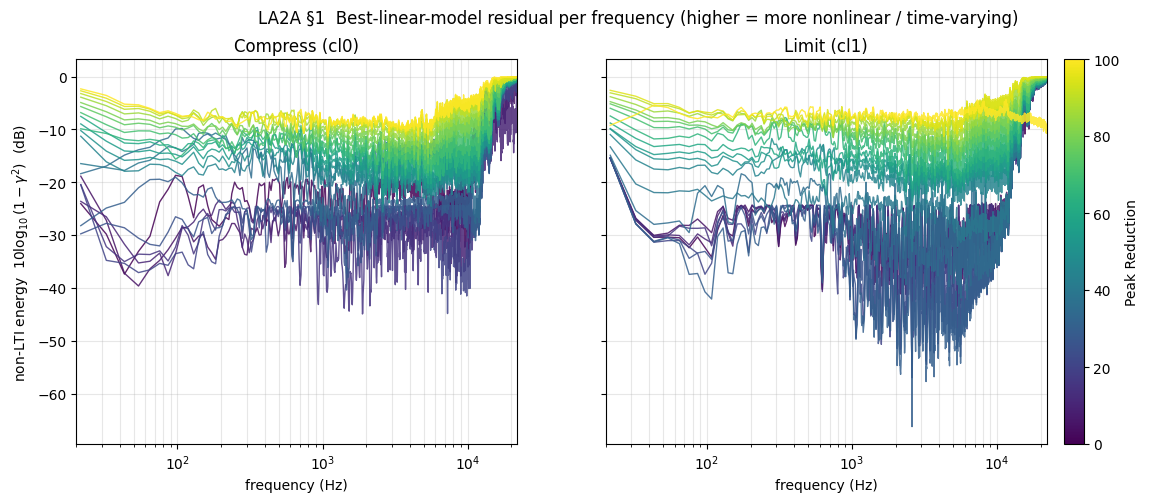

Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered hardest -> softest:
  cl1_pr100     NMSE =   -7.16 dB
  cl0_pr100     NMSE =   -8.48 dB
  cl1_pr95      NMSE =   -7.64 dB
  cl0_pr95      NMSE =   -8.13 dB
  cl1_pr90      NMSE =   -7.93 dB
  cl0_pr90      NMSE =   -8.60 dB
  cl1_pr85      NMSE =   -8.79 dB
  cl0_pr85      NMSE =   -8.79 dB
  cl1_pr80      NMSE =   -9.92 dB
  cl0_pr80      NMSE =  -10.35 dB
  cl1_pr75      NMSE =  -10.15 dB
  cl0_pr75      NMSE =  -11.44 dB
  cl1_pr70      NMSE =  -10.36 dB
  cl0_pr70      NMSE =  -13.18 dB
  cl1_pr65      NMSE =  -11.99 dB
  cl0_pr65      NMSE =  -12.41 dB
  cl1_pr60      NMSE =  -15.14 dB
  cl0_pr60      NMSE =  -12.81 dB
  cl1_pr55      NMSE =  -16.58 dB
  cl0_pr55      NMSE =  -14.38 dB
  cl1_pr50      NMSE =  -15.62 dB
  cl0_pr50      NMSE =  -15.68 dB
  cl1_pr45      NMSE =  -17.16 dB
  cl0_pr45      NMSE =  -16.44 dB
  cl1_pr40      NMSE =  -23.42 dB
  cl0_pr40      NMSE =  -16.41 dB
  cl1_pr35      NMSE =  -23.36 dB
  cl0_pr35    

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, comp in zip(axes, (0, 1)):
    for setting in SETTINGS:
        c, pr = setting_comp_pr(setting)
        if c != comp:
            continue
        acc = results[setting]["acc"]
        unexp_db = 10 * np.log10(acc.linear_unexplained() + EPS)
        ax.semilogx(FREQS[fmask], unexp_db[fmask], color=PR_CMAP(PR_NORM(pr)), lw=1.0, alpha=0.85)
    ax.set_xlabel("frequency (Hz)")
    ax.set_title("Compress (cl0)" if comp == 0 else "Limit (cl1)")
    ax.set_xlim(F_MIN, F_MAX)
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel(r"non-LTI energy  $10\log_{10}(1-\gamma^2)$  (dB)")
fig.suptitle("LA2A §1  Best-linear-model residual per frequency (higher = more nonlinear / time-varying)")
sm = ScalarMappable(norm=PR_NORM, cmap=PR_CMAP); sm.set_array([])
fig.colorbar(sm, ax=axes, label="Peak Reduction", pad=0.015)
plt.show()

print("Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered hardest -> softest:")
for setting in SETTINGS_BY_SEV:
    acc = results[setting]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    print(f"  {setting:12s}  NMSE = {10*np.log10(nmse + EPS):7.2f} dB")

## §2 — Gain-matched residual spectrum

Remove the compressor's level/dynamics with the broadband GR envelope `g(t)`
(here `gr_db = gain_reduction_db(dry, wet, 1024)`, the grey-box front-end used
across this project), then inspect the spectrum of the leftover `r = wet − g·dry`.
A pure broadband gain would leave `r ≈ 0`; what actually remains is the LA-2A's
frequency-dependent **coloration + harmonic distortion**. Curves: residual-to-
output ratio `10·log10(Srr/Syy)` per frequency.

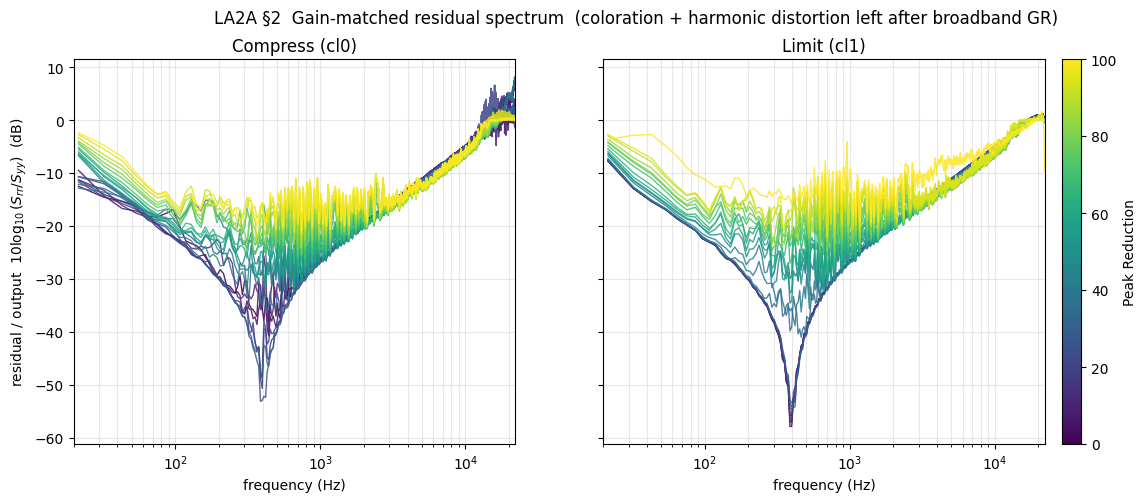

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, comp in zip(axes, (0, 1)):
    for setting in SETTINGS:
        c, pr = setting_comp_pr(setting)
        if c != comp:
            continue
        acc = results[setting]["acc"]
        dr_db = 10 * np.log10(acc.distortion_ratio() + EPS)
        ax.semilogx(FREQS[fmask], dr_db[fmask], color=PR_CMAP(PR_NORM(pr)), lw=1.0, alpha=0.85)
    ax.set_xlabel("frequency (Hz)")
    ax.set_title("Compress (cl0)" if comp == 0 else "Limit (cl1)")
    ax.set_xlim(F_MIN, F_MAX)
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel(r"residual / output  $10\log_{10}(S_{rr}/S_{yy})$  (dB)")
fig.suptitle("LA2A §2  Gain-matched residual spectrum  (coloration + harmonic distortion left after broadband GR)")
sm = ScalarMappable(norm=PR_NORM, cmap=PR_CMAP); sm.set_array([])
fig.colorbar(sm, ax=axes, label="Peak Reduction", pad=0.015)
plt.show()

### Listen — gain-matched residual

The residual `r = wet − g·dry` is exactly the time-domain signal whose spectrum
the cell above plots (the STFT is linear, so `STFT(r) = Y − M`). Subtracting the
broadband gain `g(t)` removes the compressor's level/dynamics and leaves only its
**frequency-dependent coloration + harmonic distortion** — which you can now hear.

The players below render a short excerpt of the hardest setting. The first three (dry,
wet, gain-matched) share a common scale so the compression stays audible across
them; the **residual is peak-normalized** because it is much quieter than the
output (see the printed residual/output level in dB).

In [ ]:
# ---- Listen to the gain-matched residual  r = wet − g·dry  (the audible nonlinearity) ----
from IPython.display import Audio, display

LISTEN_SECONDS = 25.0      # excerpt length rendered as audio players
LISTEN_OFFSET_SEC = 30.0   # skip in to land on musical material (clamped to fit the file)


def _clamp_offset(offset_sec, total, seconds):
    o = int(round(offset_sec * SAMPLE_RATE))
    return min(o, max(total - int(round(seconds * SAMPLE_RATE)), 0))


def residual_excerpt(setting, seconds=LISTEN_SECONDS, offset_sec=LISTEN_OFFSET_SEC):
    """Time-domain dry / wet / gain-matched / residual (wet − g·dry) excerpt
    for the first pair of one setting (GR computed on the fly, as in the spectrum cell)."""
    p = SETTING_PAIRS[setting][0]
    total = _pair_num_frames(p["dry"], p["wet"], SAMPLE_RATE)
    o = _clamp_offset(offset_sec, total, seconds)
    stop = min(o + int(round(seconds * SAMPLE_RATE)), total)
    dry, wet = _read_dry_wet_segment(p["dry"], p["wet"], o, stop, SAMPLE_RATE)
    L = min(dry.shape[-1], wet.shape[-1])
    dry, wet = dry[..., :L], wet[..., :L]
    gr_db = gain_reduction_db(dry, wet, RMS_WINDOW).clamp(GR_DB_MIN, GR_DB_MAX)
    matched = dry * gr_db_to_gain(gr_db, clamp=False)
    res = wet - matched
    sq = lambda t: t.squeeze(0).numpy()
    return sq(dry), sq(wet), sq(matched), sq(res)


def play_residual(item, title=None):
    """Render dry / wet / gain-matched / residual audio players for one item."""
    dry, wet, matched, res = residual_excerpt(item)
    rms = lambda a: float(np.sqrt(np.mean(a ** 2)) + EPS)
    print(f"{title or item}")
    print(f"  residual/output = {20*np.log10(rms(res)/rms(wet)):5.1f} dB   "
          f"(peaks: wet {np.max(np.abs(wet)):.3f}, residual {np.max(np.abs(res)):.4f})")
    shared = max(np.max(np.abs(dry)), np.max(np.abs(wet)), np.max(np.abs(matched)), EPS)
    rpk = max(np.max(np.abs(res)), EPS)
    for name, sig, sc in [
        ("dry  x", dry, shared),
        ("wet  y", wet, shared),
        ("gain-matched  g·x   (broadband GR removed)", matched, shared),
        ("residual  r = y − g·x   [peak-normalized — the audible nonlinearity]", res, rpk),
    ]:
        print("  " + name)
        display(Audio(sig / sc, rate=SAMPLE_RATE, normalize=False))


# Listen to the hardest setting (set to any key in SETTINGS_BY_SEV).
play_residual(HARDEST, title=f"{HARDEST}  (pair {SETTING_PAIRS[HARDEST][0]['id']})")


## §3 — Envelope multiple-coherence

Add the envelope-modulated input `m = g·dry` as a **second regressor** and compute
the multiple coherence `γ²_{y:(x,m)}`. Because `g(t)` varies *within* each window,
`STFT(g·x) ≠ g·STFT(x)` — `m` carries genuinely new (modulation-spread) structure,
so the 2×2 cross-spectral matrix is well-conditioned. The **gap**
`γ²_{y:(x,m)} − γ²_{yx}` is the output power explained *only* once the time-varying
gain is admitted — a direct, per-frequency signature of the envelope-driven
nonlinearity. Top: ordinary vs multiple coherence for the hardest setting.
Bottom: the gap for every setting, **split by mode** (Compress left, Limit right;
coloured by peak-reduction).

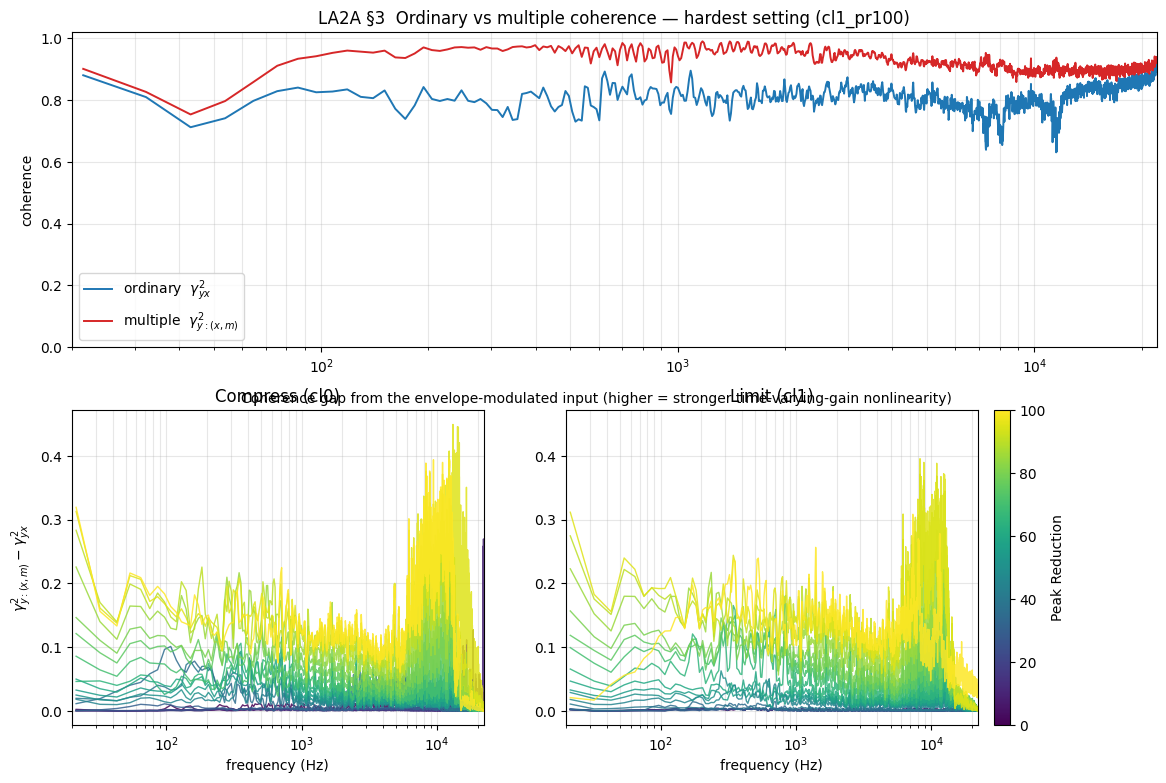

In [ ]:
fig, axd = plt.subplot_mosaic(
    [["top", "top"], ["compress", "limit"]], figsize=(14, 9),
)
ax_top, ax_c, ax_l = axd["top"], axd["compress"], axd["limit"]

acc_h = results[HARDEST]["acc"]
ax_top.semilogx(FREQS[fmask], acc_h.coherence()[fmask], lw=1.4,
                color="#1f77b4", label=r"ordinary  $\gamma^2_{yx}$")
ax_top.semilogx(FREQS[fmask], acc_h.multiple_coherence()[fmask], lw=1.4,
                color="#d62728", label=r"multiple  $\gamma^2_{y:(x,m)}$")
ax_top.set_ylabel("coherence")
ax_top.set_ylim(0, 1.02)
ax_top.set_xlim(F_MIN, F_MAX)
ax_top.set_title(f"LA2A §3  Ordinary vs multiple coherence — hardest setting ({HARDEST})")
ax_top.grid(True, which="both", alpha=0.3)
ax_top.legend(loc="lower left")

for ax, comp in ((ax_c, 0), (ax_l, 1)):
    for setting in SETTINGS:
        c, pr = setting_comp_pr(setting)
        if c != comp:
            continue
        acc = results[setting]["acc"]
        gap = acc.multiple_coherence() - acc.coherence()
        ax.semilogx(FREQS[fmask], gap[fmask], color=PR_CMAP(PR_NORM(pr)), lw=1.0, alpha=0.85)
    ax.set_xlabel("frequency (Hz)")
    ax.set_title("Compress (cl0)" if comp == 0 else "Limit (cl1)")
    ax.set_xlim(F_MIN, F_MAX)
    ax.grid(True, which="both", alpha=0.3)
ax_c.set_ylabel(r"$\gamma^2_{y:(x,m)} - \gamma^2_{yx}$")
# Shared y-range so the two gap panels are directly comparable.
ylo = min(ax_c.get_ylim()[0], ax_l.get_ylim()[0])
yhi = max(ax_c.get_ylim()[1], ax_l.get_ylim()[1])
ax_c.set_ylim(ylo, yhi); ax_l.set_ylim(ylo, yhi)
fig.suptitle("Coherence gap from the envelope-modulated input (higher = stronger time-varying-gain nonlinearity)",
             y=0.48, fontsize=10)
sm = ScalarMappable(norm=PR_NORM, cmap=PR_CMAP); sm.set_array([])
fig.colorbar(sm, ax=[ax_c, ax_l], label="Peak Reduction", pad=0.015)
plt.show()

## §4 — Bicoherence (quadratic phase coupling)

The third-order analogue of coherence:

$$b^2(f_1,f_2)=\frac{\left|\;\mathbb{E}\!\left[X(f_1)X(f_2)X^*(f_1{+}f_2)\right]\right|^2}
{\mathbb{E}|X(f_1)X(f_2)|^2\;\cdot\;\mathbb{E}|X(f_1{+}f_2)|^2}.$$

It is ~0 for a linear process with independent-phase components and rises toward 1
where a **quadratic** nonlinearity phase-locks `f_1`, `f_2` and their sum.
Computed on one excerpt of the hardest setting (`cl1_pr100`), decimated for
tractability. The **wet** map showing structure absent from the **dry** map is
nonlinearly-generated coupling — proof the box is not linear, independent of any
envelope model.

Bicoherence: cl1_pr100 (id 179)  | 11025 Hz, n_fft=256, 129 bins, excerpt 60s


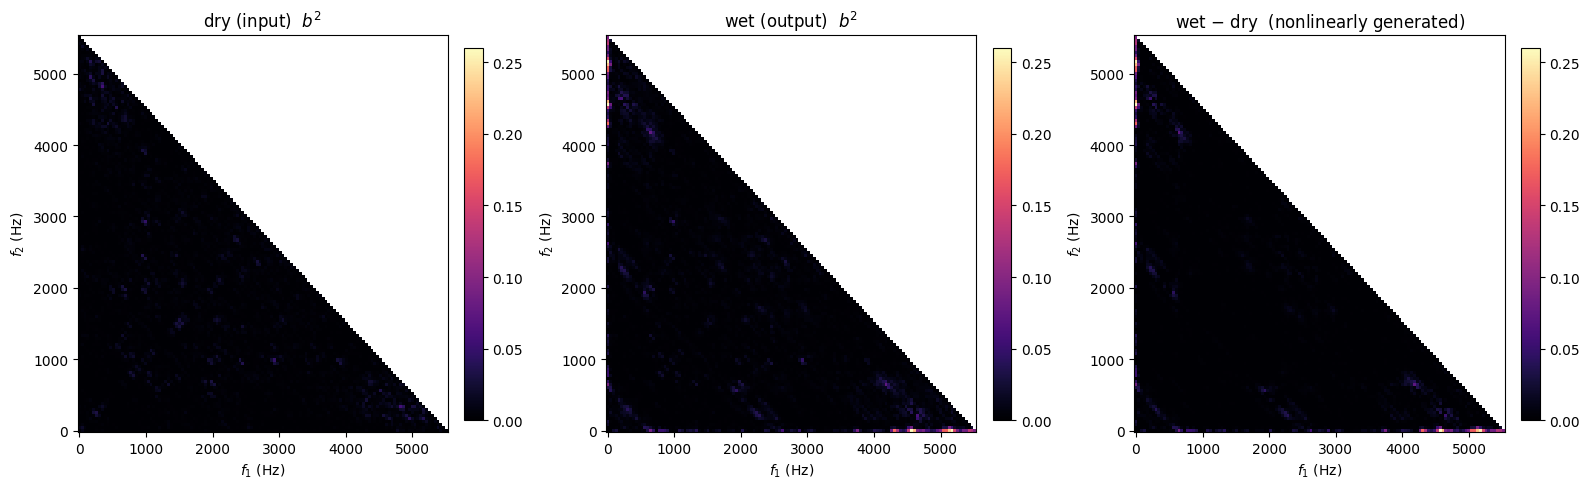

mean bicoherence  dry=0.0024   wet=0.0042   (wet/dry = 1.72x)


In [ ]:
# Decimated, single excerpt of the hardest setting (bicoherence is O(F^2)).
BIC_SR = 11025
BIC_NFFT = 256
BIC_HOP = BIC_NFFT // 2
BIC_PAIR = SETTING_PAIRS[HARDEST][0]
BIC_DUR_SEC = 60.0

_total = _pair_num_frames(BIC_PAIR["dry"], BIC_PAIR["wet"], SAMPLE_RATE)
_stop = min(_total, int(BIC_DUR_SEC * SAMPLE_RATE))
_dry, _wet = _read_dry_wet_segment(BIC_PAIR["dry"], BIC_PAIR["wet"], 0, _stop, SAMPLE_RATE)
dry_ds = librosa.resample(_dry.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)
wet_ds = librosa.resample(_wet.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)


def bicoherence(sig, nfft, hop):
    S = librosa.stft(np.ascontiguousarray(sig, np.float32), n_fft=nfft,
                     hop_length=hop, window="hann", center=False)   # [F, T]
    F = S.shape[0]
    idx = np.arange(F)
    s = idx[:, None] + idx[None, :]
    valid = s < F
    s_clip = np.where(valid, s, 0)
    num = np.zeros((F, F), np.complex128)
    d1 = np.zeros((F, F), np.float64)
    d2 = np.zeros((F, F), np.float64)
    for t in range(S.shape[1]):
        Xt = S[:, t]
        prod = np.outer(Xt, Xt)            # X(f1) X(f2)
        Xsum = Xt[s_clip]                  # X(f1+f2)
        num += prod * np.conj(Xsum)
        d1 += np.abs(prod) ** 2
        d2 += np.abs(Xsum) ** 2
    b2 = (np.abs(num) ** 2) / (d1 * d2 + EPS)
    b2[~valid] = np.nan
    return b2, librosa.fft_frequencies(sr=BIC_SR, n_fft=nfft)


b2_dry, bfreq = bicoherence(dry_ds, BIC_NFFT, BIC_HOP)
b2_wet, _ = bicoherence(wet_ds, BIC_NFFT, BIC_HOP)
print(f"Bicoherence: {HARDEST} (id {BIC_PAIR['id']})  | {BIC_SR} Hz, n_fft={BIC_NFFT}, "
      f"{b2_dry.shape[0]} bins, excerpt {_stop/SAMPLE_RATE:.0f}s")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in zip(
    axes,
    [b2_dry, b2_wet, b2_wet - b2_dry],
    ["dry (input)  $b^2$", "wet (output)  $b^2$", "wet $-$ dry  (nonlinearly generated)"],
):
    pm = ax.pcolormesh(bfreq, bfreq, data, shading="auto", cmap="magma",
                       vmin=0, vmax=(np.nanmax(b2_wet) if "generated" not in title else None))
    ax.set_title(title)
    ax.set_xlabel("$f_1$ (Hz)")
    ax.set_ylabel("$f_2$ (Hz)")
    fig.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print(f"mean bicoherence  dry={np.nanmean(b2_dry):.4f}   wet={np.nanmean(b2_wet):.4f}   "
      f"(wet/dry = {np.nanmean(b2_wet)/ (np.nanmean(b2_dry)+EPS):.2f}x)")

## Summary

Per setting (hardest → softest), the four nonlinearity read-outs over the
200 Hz–8 kHz band. Ordinary coherence is shown for reference — note how little it
moves while the targeted measures separate the settings.

In [ ]:
rows = []
for setting in SETTINGS_BY_SEV:
    comp, pr = setting_comp_pr(setting)
    acc = results[setting]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    rows.append({
        "Setting": setting,
        "Mode": "Compress" if comp == 0 else "Limit",
        "PeakRed": pr,
        "Frames": acc.n_frames,
        "ord. coh (ref)": float(np.mean(acc.coherence()[band])),
        "§1 best-LTI NMSE dB": 10 * np.log10(nmse + EPS),
        "§2 resid/out dB": float(np.mean(10 * np.log10(acc.distortion_ratio()[band] + EPS))),
        "§3 multi-coh gap": float(np.mean((acc.multiple_coherence() - acc.coherence())[band])),
    })
summary_df = pd.DataFrame(rows)
display(summary_df.round(4))

,Setting,Mode,PeakRed,Frames,ord. coh (ref),§1 best-LTI NMSE dB,§2 resid/out dB,§3 multi-coh gap
0,cl1_pr100,Limit,100,15444,0.7967,-7.1645,-9.6948,0.1383
1,cl0_pr100,Compress,100,10296,0.8349,-8.4791,-12.9911,0.1336
2,cl1_pr95,Limit,95,10296,0.8240,-7.6407,-12.7022,0.1421
3,cl0_pr95,Compress,95,10296,0.8349,-8.1326,-13.0572,0.1348
4,cl1_pr90,Limit,90,10296,0.8362,-7.9347,-12.8766,0.1323
5,cl0_pr90,Compress,90,10296,0.8594,-8.6029,-13.3758,0.1138
6,cl1_pr85,Limit,85,10296,0.8783,-8.7934,-13.4674,0.0975
7,cl0_pr85,Compress,85,10296,0.8892,-8.7902,-13.9730,0.0905
8,cl1_pr80,Limit,80,10296,0.9160,-9.9211,-13.9898,0.0665
9,cl0_pr80,Compress,80,10296,0.9241,-10.3530,-14.1718,0.0599
